# Notebook 16 (V4_3) — Notebook 15 Calibration with a Realized Switch at Period 16

This notebook applies the AHP-pattern calibration selected in Notebook 15 to a realized history in which the economy is in regime $u$ for periods $1,\ldots,15$ and in the absorbing regime $b$ from period 16 onward. It reproduces Section 2 of Notebook 05 at this calibration and exports numerical validation tables.

## 1. Review of the Notebook 05 switch construction

The deterministic construction in Notebook 05 is the right model simulation for a **realized, unannounced stochastic switch**. With $\tau=16$, periods 1–15 use the solved $u$ policy. Period 16 inherits the knowledge stocks produced by the period-15 $u$ allocation, selects the absorbing equilibrium at that inherited state, and all later knowledge stocks are advanced using the realized $b$ allocations. One must therefore re-solve the absorbing equilibrium along the realized post-switch state path; simply splicing later entries of `bgp_seq` onto the $u$ path would be incorrect because those entries lie on the counterfactual all-$u$ knowledge path.

Two qualifications matter. First, agents before period 16 continue to price the hazard $1-\pi$ every period; period 16 is not a deterministic burst date anticipated in advance. Second, Notebook 05's separate Monte Carlo cell draws before recording the initially stated $u$ period and can consequently report $\tau=1$; that off-by-one issue does not affect its deterministic Section 2 construction or this notebook.

For the Notebook 15 calibration, the companion implementation also validates every realized absorbing solve and carries the preceding state's effective exponent as the next common-growth solver seed. This is a numerical-continuation safeguard: it preserves the same state-specific common-growth condition while preventing a failed solve from silently introducing `NaN` values.

## 2. Plot the V4_3 Transition: Notebook 15 Calibration at $\tau=16$

The first figure has seven panels. The price-dividend ratio, labor allocation, aggregate market capitalization, output, and labor-income panels plot both the U.S. and RoW simulated quantities. The sixth panel plots the portfolio weights $\omega_t$ and $\omega_t^*$, and the final full-width panel retains the U.S.-only rebased NFA change. That last panel uses Notebook 15's normalization, $(NFA_{US,t}-NFA_{US,1})/Y_{US,t}$, rather than the NFA level ratio. Dotted country-colored lines show the corresponding no-switch all-$u$ paths for price-dividend ratios, market capitalizations, labor incomes, and portfolio weights; the U.S. NFA counterfactual is gray and dotted. The second figure applies Notebook 15's exact AHP accounting to the realized switch path and shows aggregate VA and CA effects alongside their asset, liability, and bond subcomponents. The absorbing $b$ branch is fundamental by equilibrium selection; a fall in $q/d$ is not itself the definition of a burst. At this calibration the U.S. equity price falls at the switch, but its dividend falls more, so its $q/d$ rises and then stabilizes.

  Activating 

Notebook 15 selected calibration: pathwise_hi_exp_pi075

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Switch convention: u for t < 16, b for t >= 16
Output directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_calibration_switch_at_16
Cold all-u solve: converged=true, max u residual=1.147e-09, max BGP residual=9.757e-10
Reference calibrated nu_b: 1.660652987 (Notebook 15 export 1.660652987)

Switch event at t=16
  q_US/d_US: t15 31.269505 -> t16 b 36.368309 (+16.306%); t16 all-u 31.411825
  q_US:      t15 1.324484 -> t16 b 1.062493 (-19.781%)
  d_US:      t15 0.042357 -> t16 b 0.029215 (-31.027%)
  Y_US:      t15 3.507377 -> t16 b 2.016691 (-42.501%)
  rebased NFA/current Y: t15 -0.037937 -> t16 b -0.263835; t16 all-u -0.036889
  period-16 effects/current Y: VA +0.038028, CA -0.235885, residual +0.000e+00
  cumulative effects/current Y at t16: VA -0.046593, CA -0.217242, residual +0.000e+00
  realized nu_b_eff range: [0.788354623, 0.788354645], span 2.198e-08
  maximum b residual: 9.728e-10; c

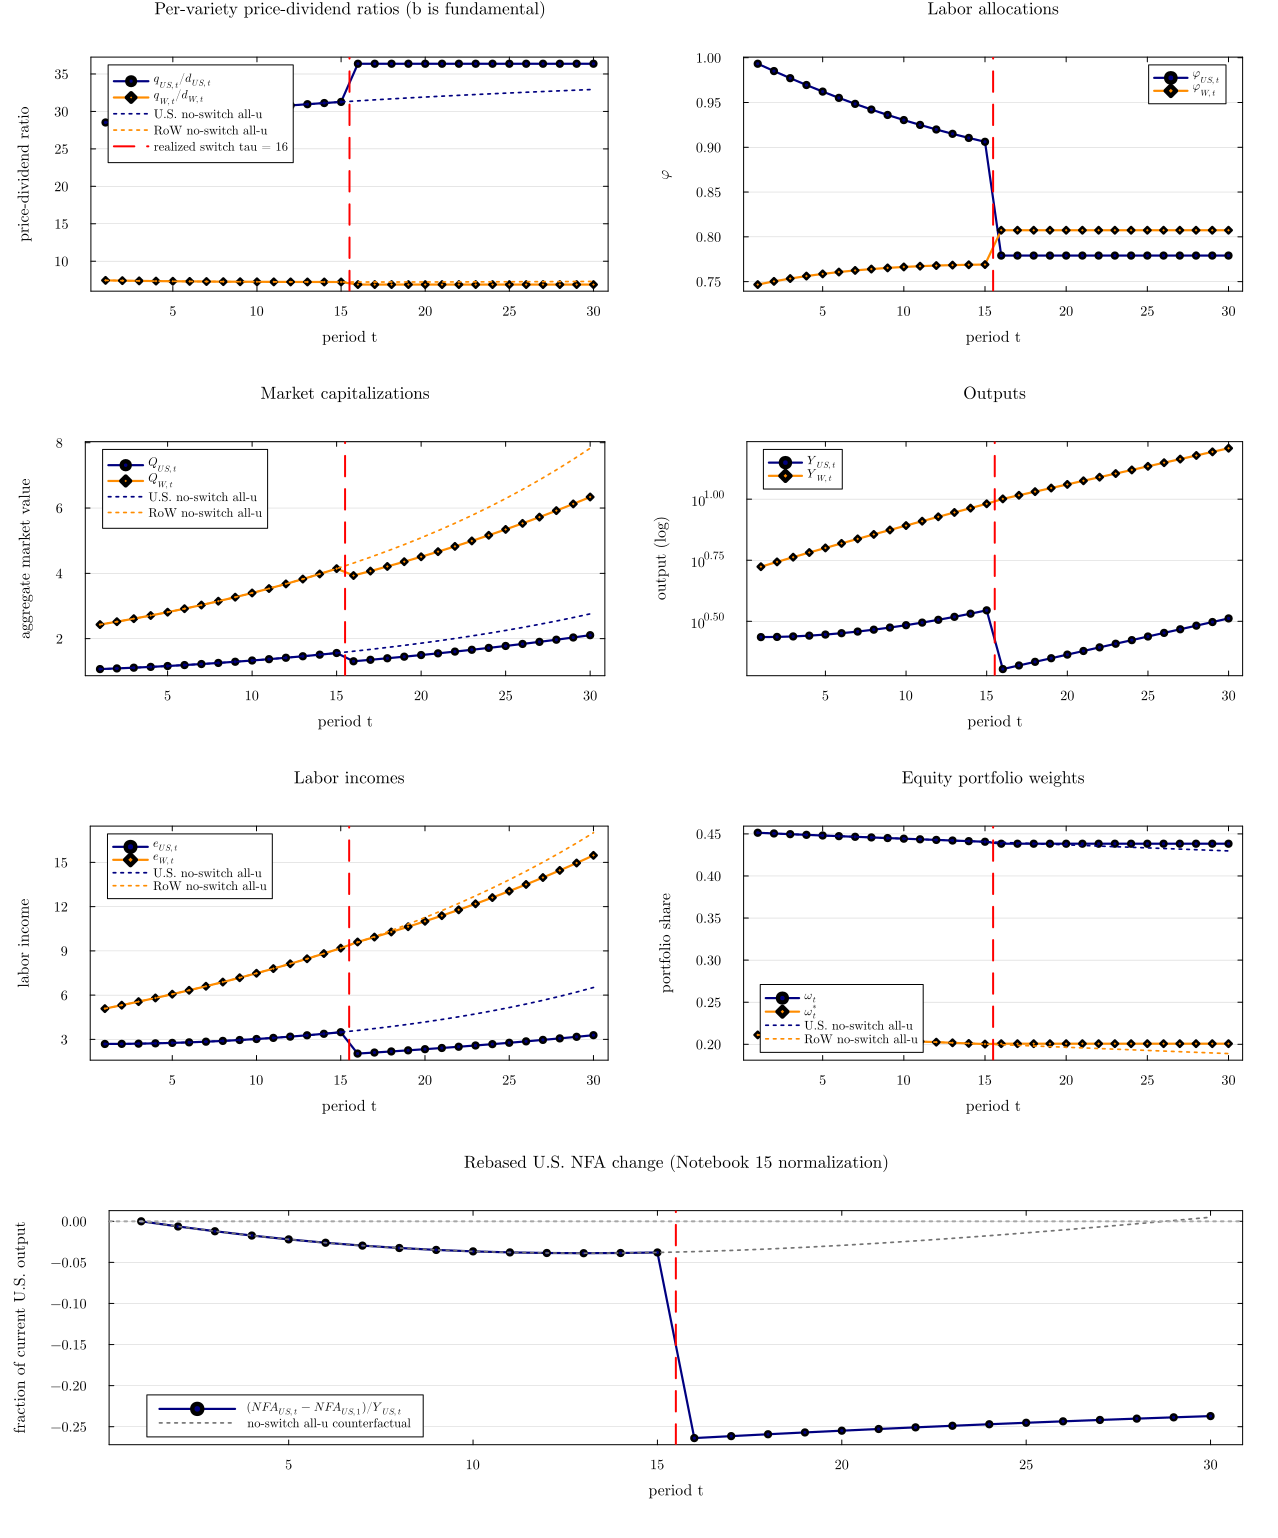

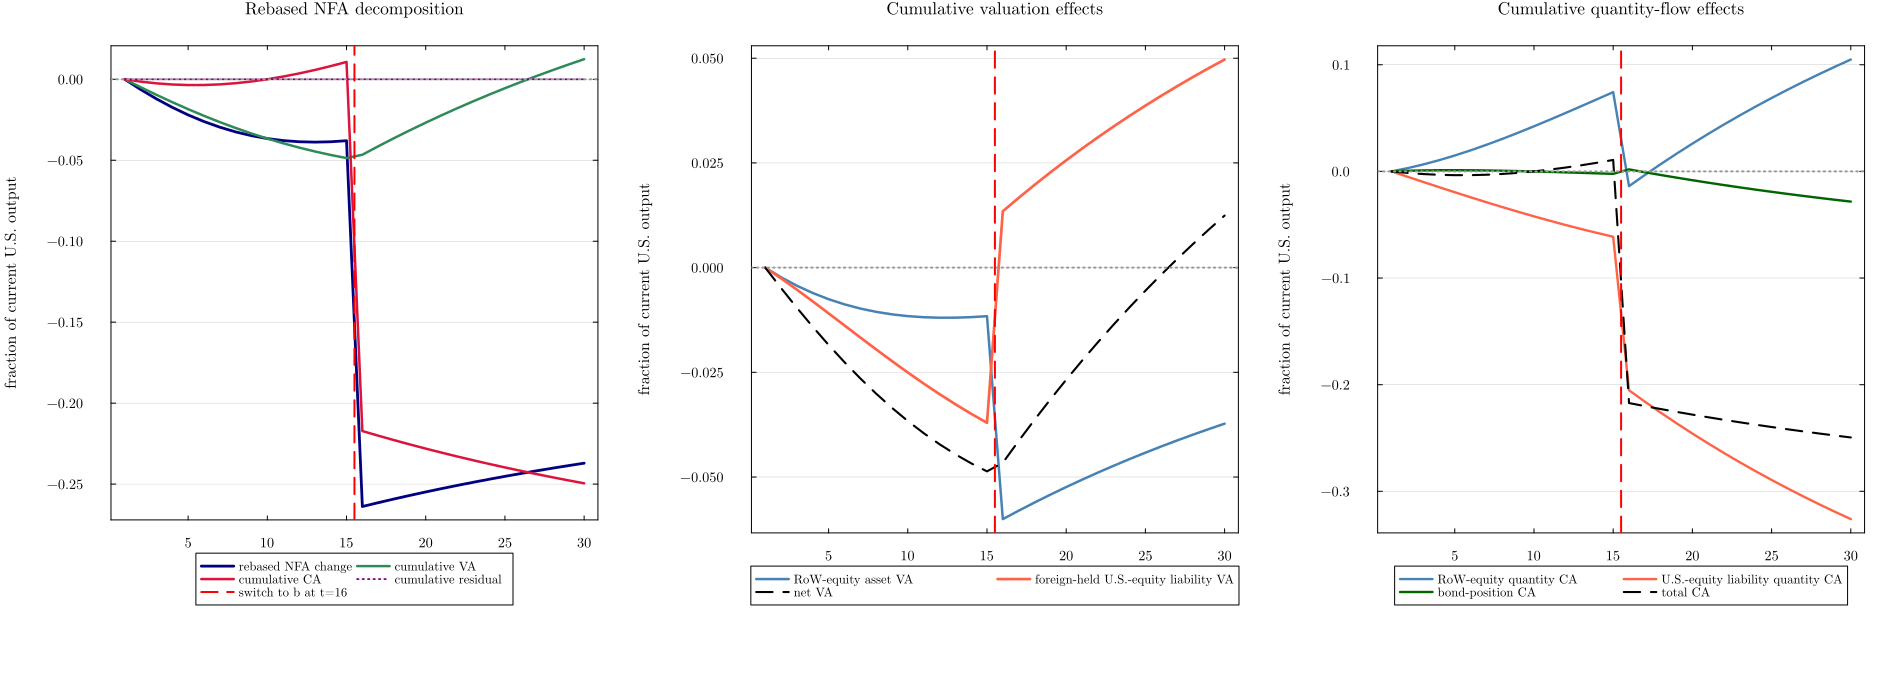

In [1]:
notebook_dir = if isfile(joinpath(pwd(), "16_v9_ahp_calibration_switch_at_16.jl"))
    pwd()
elseif isfile(joinpath(pwd(), "Two_country_production", "16_v9_ahp_calibration_switch_at_16.jl"))
    joinpath(pwd(), "Two_country_production")
else
    error("Run this notebook from the repository root or Two_country_production directory.")
end
include(joinpath(notebook_dir, "16_v9_ahp_calibration_switch_at_16.jl"))

## 3. VA and CA accounting at the switch

Notebook 15's AHP accounting decomposes each equity position exactly. For a foreign asset $q_{W,t}n_{W,t}$, $VA_t^{asset}=n_{W,t-1}(q_{W,t}-q_{W,t-1})$ holds inherited quantities fixed and $CA_t^{asset}=q_{W,t}(n_{W,t}-n_{W,t-1})$ values the quantity flow at the current price. The liability formulas carry a minus sign because foreign-held U.S. equity is an NFA liability. The bond has no separate price revaluation, so its position change enters CA. Consequently $\Delta NFA_t=VA_t+CA_t+RES_t$ exactly; the numerical residual at the switch is zero.

At period 16, the **valuation effect of the burst improves U.S. NFA**. The U.S. equity-price decline lowers the value of foreigners' inherited U.S. claims, contributing $+0.1571$, while the simultaneous RoW-equity price movement reduces the value of U.S.-held foreign claims by $-0.0804$. Net period-16 VA is therefore $+0.0767$, or $+3.80\%$ of period-16 U.S. output.

The **CA quantity-flow effect dominates in the opposite direction**. U.S.-held RoW equity falls by $-0.2885$, the increase in foreign-held U.S. equity quantities contributes $-0.1990$, and the bond position improves NFA by only $+0.0118$. Net period-16 CA is $-0.4757$, or $-23.59\%$ of current output. Hence $\Delta NFA_{16}=0.0767-0.4757=-0.3990$: the favorable burst revaluation is overwhelmed by adverse portfolio quantity adjustment. This is the VA/CA version of the equivalent identity $NFA_t=\beta e_{US,t}-Q_{US,t}$: labor income and saving fall so much that the associated contraction and reallocation of U.S. asset holdings outweigh the benefit from the lower market value of U.S. equity liabilities.

Cumulatively, just before the burst, VA is $-4.87\%$ and CA is $+1.07\%$ of current output, giving the rebased NFA change of $-3.79\%$. At period 16, cumulative VA is still only $-4.66\%$, whereas cumulative CA jumps to $-21.72\%$; together they give $-26.38\%$. Thus the abrupt post-switch deterioration in this calibration is **CA-dominated**, even though the pre-switch AHP-pattern decline was VA-dominated. The plotted rebased series falls by 22.59 percentage points from periods 15 to 16: 19.79 points come from the NFA-level change divided by new output, and another 2.80 points come from dividing the already accumulated negative change by an output denominator that falls $42.5\%$.

`rebased_nfa_components_t16.csv` exports every period VA/CA term and its current-output normalization. `switch_event_summary.csv` separates the adjacent-date change from the realized-$b_{16}$ versus counterfactual-$u_{16}$ comparison. `simulation_validation.csv` checks timing, post-switch recursions, equilibrium convergence, common growth, NFA identities, and the exact VA/CA adding-up conditions. Reproduction within this repository uses the tracked Notebook 15 `candidate_summary.csv`, the shared model module, and the companion `16_v9_ahp_calibration_switch_at_16.jl`.